**Trabajo Práctico 1: Regresión**

## **Exploración de Datos**
### **Carga del Dataset y Corrección de Datos**
Para comenzar, cargamos el dataset `casas_dev.csv` y exploramos sus primeras filas para entender su estructura.

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))
from src import graficos, hiperparams, metrics, models, preprocessing, utils

In [146]:
df = pd.read_csv("../data/casas_dev.csv")
df.head()

,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
0,635.0,sqft,1,0,18.0,546.0,40.679064,-74.007844,2.0
1,1098.0,sqft,0,0,9.0,759.0,40.712839,-73.967750,3.0
2,667.0,sqft,0,0,7.0,464.0,40.669863,-74.029414,2.0
3,127.0,m2,1,1,16.0,251.0,-34.600437,-58.415266,4.0
4,1378.0,sqft,0,0,8.0,963.0,40.722322,-73.983229,4.0


### **Distribuciones de las Variables**

A continuación, analizamos las distribuciones de las variables presentes en el dataset y sus valores:

- **area**: Área de la propiedad.
- **area_units**: Unidades del área (1 para m², 0 para sqft).
- **is_house**: Indicador de si la propiedad es una casa (1) o no (0).
- **has_pool**: Indicador de si la propiedad tiene piscina (1) o no (0).
- **age**: Edad de la propiedad en años.
- **price**: Precio de la propiedad.
- **lat**: Latitud de la ubicación de la propiedad.
- **lon**: Longitud de la ubicación de la propiedad.
- **rooms**: Número de habitaciones en la propiedad.

El dataset contiene 900 entradas y 9 columnas. A continuación, se muestra un resumen de las columnas y sus tipos de datos:

In [147]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        900 non-null    float64
 1   area_units  900 non-null    object 
 2   is_house    900 non-null    int64  
 3   has_pool    900 non-null    int64  
 4   age         770 non-null    float64
 5   price       900 non-null    float64
 6   lat         900 non-null    float64
 7   lon         900 non-null    float64
 8   rooms       828 non-null    float64
dtypes: float64(6), int64(2), object(1)
memory usage: 63.4+ KB


,area,is_house,has_pool,age,price,lat,lon,rooms
count,900.000000,900.000000,900.000000,770.000000,900.000000,900.000000,900.000000,828.000000
mean,533.598889,0.418889,0.144444,10.212987,466.197778,1.966225,-65.967203,2.737923
std,502.318230,0.493651,0.351735,4.773010,347.122903,37.661269,7.813671,0.948574
min,40.000000,0.000000,0.000000,1.000000,65.000000,-34.686302,-74.058238,1.000000
25%,93.000000,0.000000,0.000000,6.250000,178.750000,-34.605803,-74.005566,2.000000
50%,164.500000,0.000000,0.000000,11.000000,323.500000,-34.529704,-58.459293,3.000000
75%,980.000000,1.000000,0.000000,14.000000,712.500000,40.709819,-58.379873,3.000000
max,2164.000000,1.000000,1.000000,20.000000,1992.000000,40.764550,-58.295919,5.000000


### **Resumen del Dataset**

El método `df.info()` nos proporciona un resumen conciso del DataFrame, incluyendo el número de entradas, el nombre de las columnas, el número de valores no nulos y el tipo de datos de cada columna.

El método `df.describe()` nos proporciona estadísticas descriptivas que resumen la tendencia central, la dispersión y la forma de la distribución de un conjunto de datos.

### **Conclusiones**

1. **Valores Faltantes**:
    - Las columnas `age` y `rooms` contienen valores faltantes. Específicamente, `age` tiene 130 valores faltantes y `rooms` tiene 72 valores faltantes.
    
2. **Distribución de Datos**:
    - La columna `area` tiene un rango amplio de valores, desde 127 hasta 1378.
    - La columna `price` también muestra una variabilidad considerable, con valores que van desde 251 hasta 1245.
    
3. **Tipos de Datos**:
    - La mayoría de las columnas son de tipo `float64`, excepto `area_units`, `is_house` y `has_pool`, que son de tipo `int64`. Estos datos son booleanos.
    
4. **Unidades de Área**:
    - La columna `area_units` indica que el área está medida en diferentes unidades (1 para m² y 0 para sqft), lo cual hay que modificar.



### **Conversión de Unidades**
El dataset contiene valores de área en diferentes unidades (`m2` y `sqft`).

La función `convert_units` se encarga de convertir todas las áreas a metros cuadrados (`m2`). Para ello, mapea las unidades de área (`area_units`) a un valor numérico (1 para `sqft` y 0 para `m2`) y luego convierte las áreas medidas en `sqft` a `m2` utilizando el factor de conversión 1 `sqft` = 0.092903 `m2`. Finalmente, agrega una nueva columna `area_m2` con los valores convertidos.


In [148]:
df = preprocessing.convert_units(df)


### **Visualización de la Distribución de los Datos**
Graficamos histogramas y scatterplots para analizar las relaciones entre variables.

A continuación, se visualizan las distribuciones de las variables `area_m2`, `lat`, `rooms`, `lon` y `age` mediante histogramas. Esto nos permitirá observar la distribución de los datos y detectar posibles patrones o anomalías.

Posteriormente, se grafican scatterplots para analizar las relaciones entre las variables `age`, `area` y `price`. Estos gráficos nos ayudarán a identificar posibles correlaciones y tendencias entre las variables.


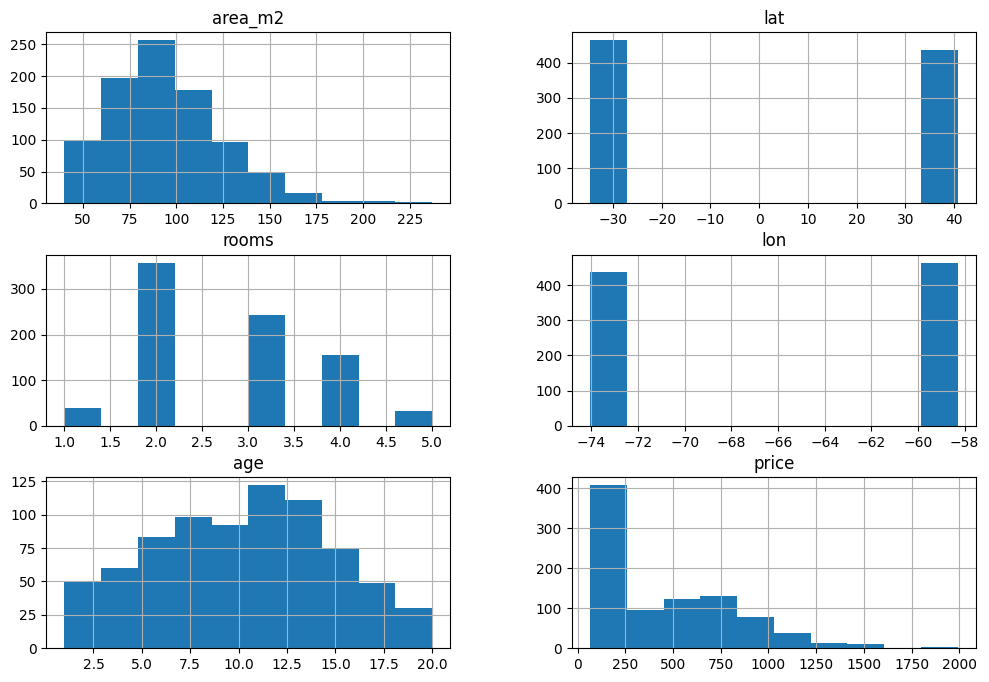

In [149]:
df[['area_m2', 'lat', 'rooms', 'lon', 'age', 'price']].hist(figsize=(12, 8))
plt.show()

### **Conclusiones del Análisis de Datos**

1. **Área y Habitaciones**:
    - Parece haber una relacion en las distribuciones de `area_m2` y `rooms`.

2. **Clusters Geográficos**:
    - Las variables `lat` y `lon` forman dos clusters cada una. Sabiendo que la latitud y longitud son coordenadas geográficas de las propiedades, podemos inferir que se forman entre 2 y 4 'barrios' en el data set.

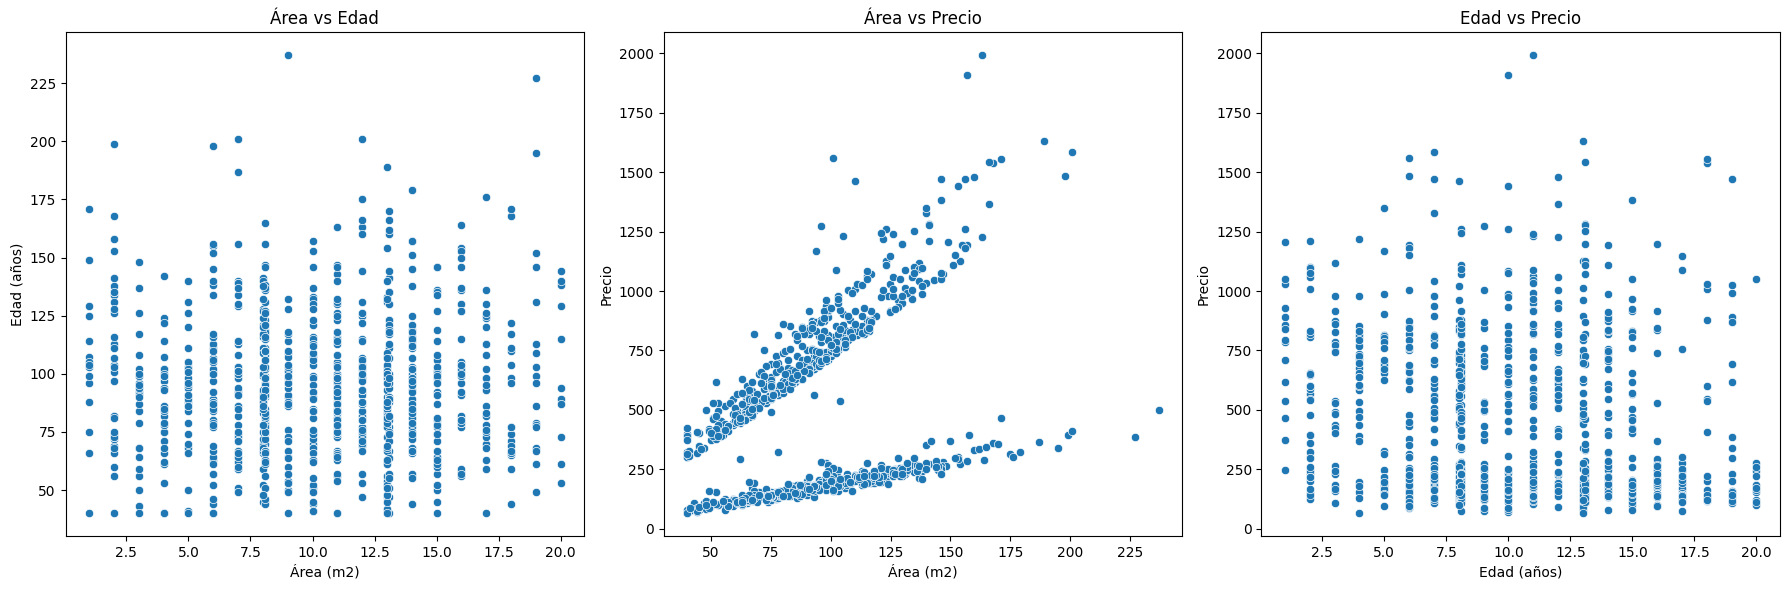

In [173]:
graficos.plot_scatterplots(df)

### **Conclusiones del Análisis de Datos**

3. **Distribución del Precio**:
    - Podemos observar en los gráficos que la variable `age` aparentemente no explica la distribución del precio, mientras que `area` sí lo hace. Parece haber dos relaciones lineales distintas para explicar los datos en función del precio.

## **Correlación de Variables**

En esta sección, analizamos la correlación entre las variables booleanas y la distribución del resto de las variables para identificar cuáles explican mejor los datos.

### **Variables Booleanas**
- **is_house**: Indicador de si la propiedad es una casa (1) o no (0).
- **has_pool**: Indicador de si la propiedad tiene piscina (1) o no (0).
- **area_units**: Unidades del área (0 para m², 1 para sqft).

### **Distribución de Variables**
- **area_m2**: Área de la propiedad en metros cuadrados.
- **age**: Edad de la propiedad en años.
- **price**: Precio de la propiedad.

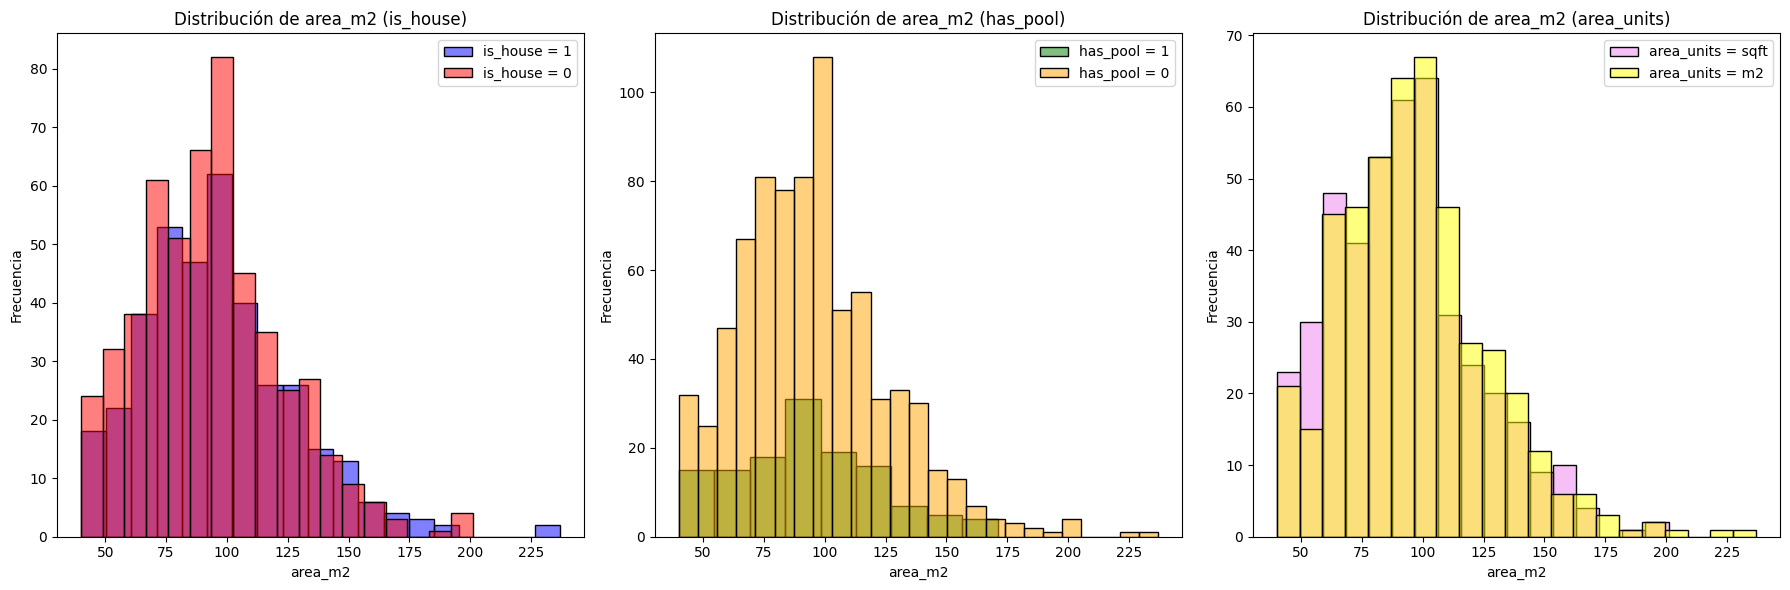

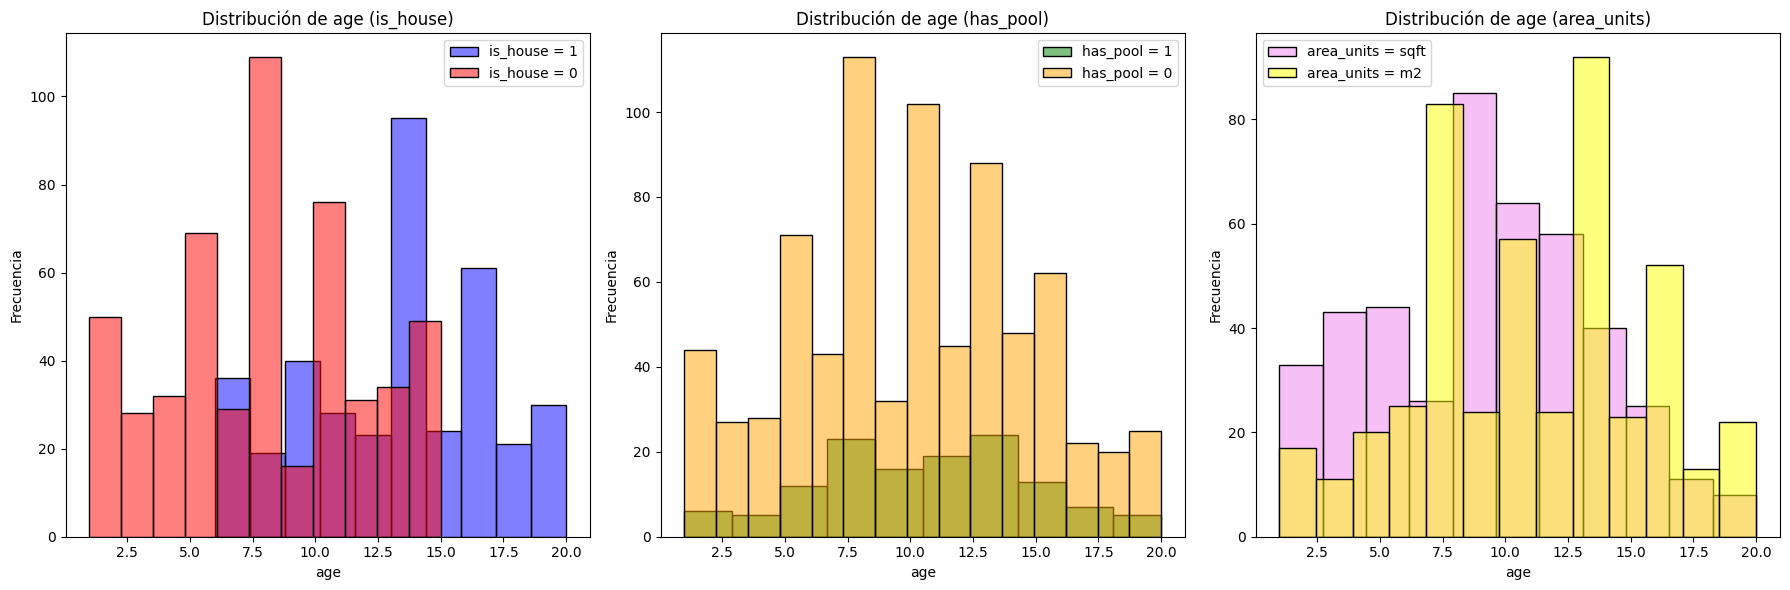

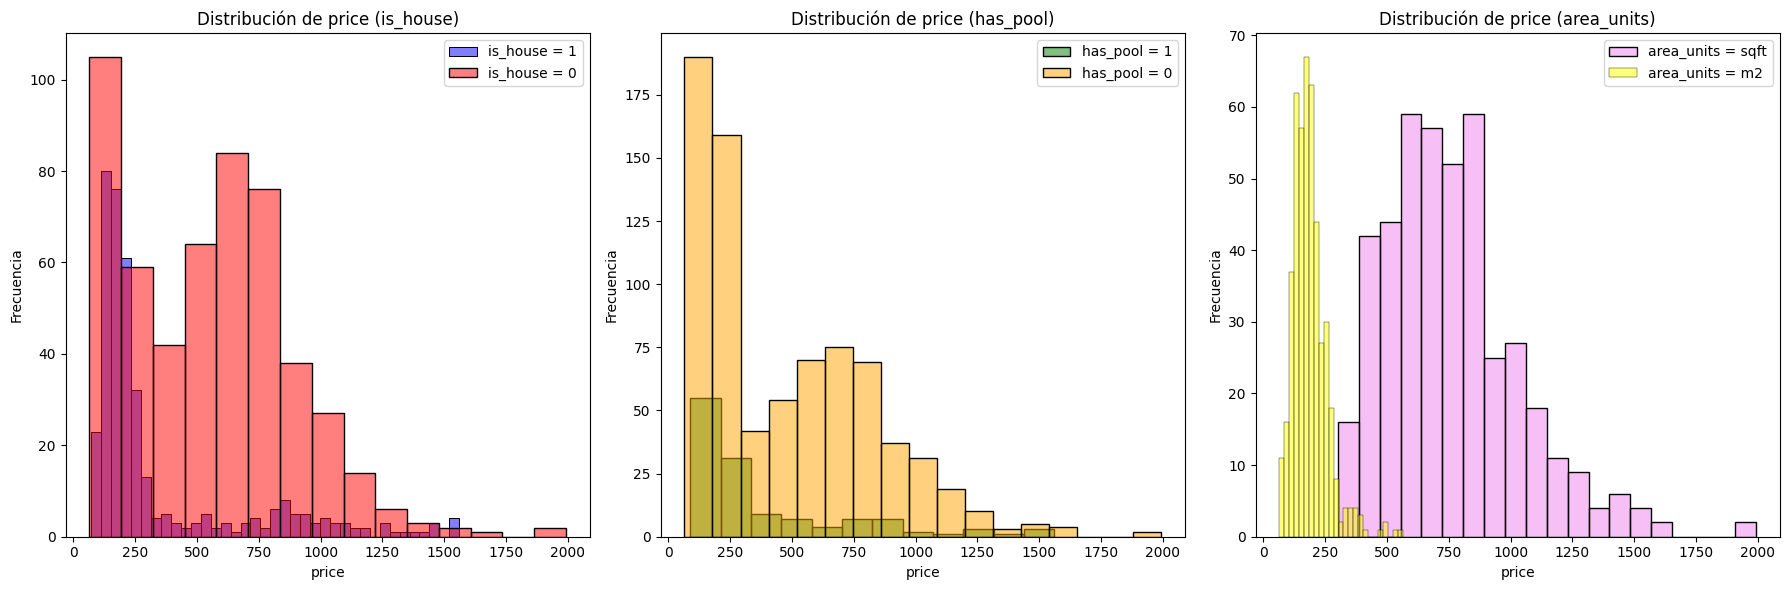

In [174]:
graficos.plot_histograms(df)

### **Conclusiones**

4. **Relación entre Edad y Tipo de Propiedad**:
    - Existe una relación notable entre la variable `age` (edad de la propiedad) y `is_house` (indicador de si la propiedad es una casa). Esto sugiere que las casas tienden a tener una distribución de edades diferente en comparación con otros tipos de propiedades.

5. **Relación entre Precio y Unidades de Área**:
    - La variable `price` (precio de la propiedad) muestra una relación con `area_units` (unidades del área). Esto indica que las propiedades medidas en diferentes unidades (m² o sqft) pueden tener diferentes rangos de precios, lo cual es importante considerar en el análisis y modelado de los datos.

### **Visualización de Clusters Geográficos**

Para profundizar en las conclusiones anteriores, vamos a graficar la latitud (`lat`) contra la longitud (`lon`) para visualizar la formación de clusters geográficos. Esta visualización nos permitirá identificar agrupaciones naturales de propiedades en el dataset.

Además, graficaremos los datos diferenciando entre las propiedades que tienen el área medida en metros cuadrados (`m2`) y aquellas medidas en pies cuadrados (`sqft`). Esto nos ayudará a observar si existe alguna relación entre las unidades de medida del área y la distribución geográfica de las propiedades.

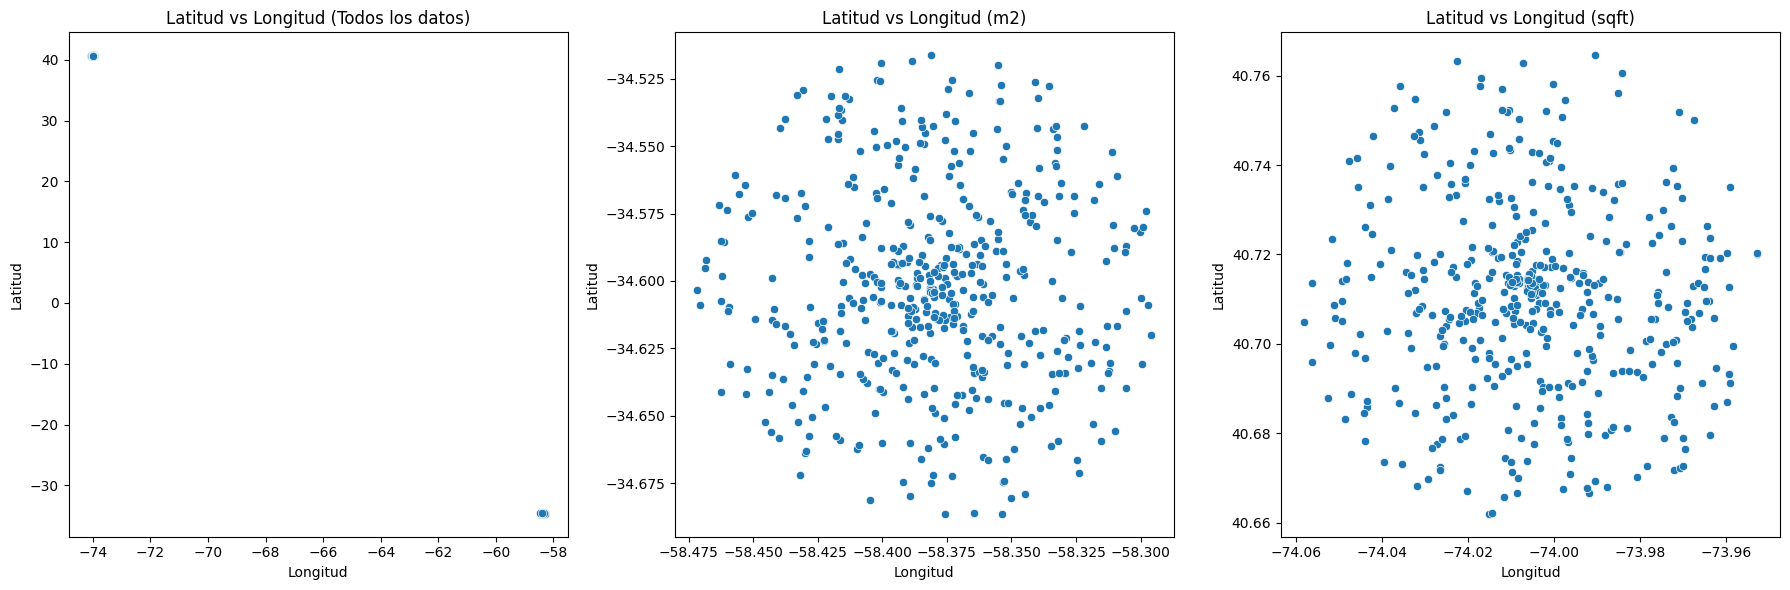

In [175]:
graficos.plot_lat_lon(df)

### **Conclusiones**

6. **Clusters Geográficos**:
    - Al graficar la latitud (`lat`) contra la longitud (`lon`), observamos la formación de dos clusters geográficos. Esto sugiere que las propiedades en el dataset se encuentran en dos ubicaciones geográficas distintas, lo cual puede ser relevante para el análisis y modelado de los datos.

7. **Unidades de Área y Clusters Geográficos**:
    - Al diferenciar las propiedades por las unidades de medida del área (`m2` y `sqft`), se observa una clara relación entre las unidades de área y los clusters geográficos.  

### **Relación entre Área y Número de Habitaciones**

En esta sección, vamos a explorar la relación entre el área de las propiedades (`area`) y el número de habitaciones (`rooms`). 

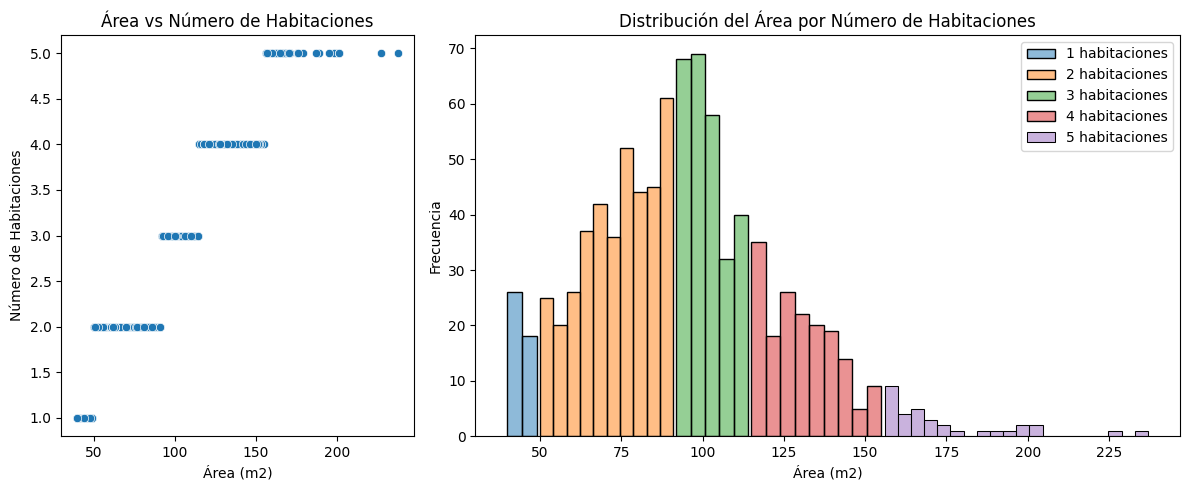

In [176]:
graficos.area_vs_rooms(df)

### **Relleno de Valores Faltantes usando KNN**

Dado que tenemos intervalos muy marcados en la cantidad de habitaciones, podemos utilizar el algoritmo K-Nearest Neighbors (KNN) para rellenar los valores faltantes de la variable `rooms` basado únicamente en la variable `area`. Esto nos permitirá imputar valores faltantes de manera más precisa y consistente.

Para la variable `age`, se divide el dataset en función de la variable `is_house` y se aplica KNN por separado en cada grupo. Esto tiene sentido ya que las casas y los edificios pueden tener distribuciones de edades diferentes.

In [154]:
df = preprocessing.impute_missing_values(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        900 non-null    float64
 1   area_units  900 non-null    int64  
 2   is_house    900 non-null    int64  
 3   has_pool    900 non-null    int64  
 4   age         900 non-null    float64
 5   price       900 non-null    float64
 6   lat         900 non-null    float64
 7   lon         900 non-null    float64
 8   rooms       900 non-null    float64
 9   area_m2     900 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 70.4 KB


In [155]:
X_train, X_val, y_train, y_val = preprocessing.split_and_normalize(df)
X_train.describe()

,area,area_units,is_house,has_pool,age,lat,lon,rooms,area_m2
count,7.200000e+02,720.000000,720.000000,720.000000,7.200000e+02,7.200000e+02,7.200000e+02,7.200000e+02,7.200000e+02
mean,2.960595e-17,0.498611,0.409722,0.141667,6.661338e-17,-4.934325e-18,1.529641e-15,-9.498575e-17,2.467162e-18
std,1.000000e+00,0.500346,0.492124,0.348950,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.005681e+00,0.000000,0.000000,0.000000,-2.036015e+00,-9.987147e-01,-1.008826e+00,-1.847778e+00,-1.841783e+00
25%,-8.959258e-01,0.000000,0.000000,0.000000,-6.984263e-01,-9.965926e-01,-1.002094e+00,-7.783245e-01,-6.980098e-01
50%,-6.225359e-01,0.000000,0.000000,0.000000,-2.963216e-02,-9.942303e-01,9.848190e-01,2.911290e-01,-5.884266e-02
75%,8.701334e-01,1.000000,1.000000,0.000000,6.609114e-01,1.002098e+00,9.964749e-01,2.911290e-01,5.803245e-01
max,3.232861e+00,1.000000,1.000000,1.000000,2.199682e+00,1.003551e+00,1.007233e+00,2.430036e+00,4.785372e+00


## **Modelado de Regresión**

Primero, vamos a entrenar un modelo de regresión lineal utilizando la pseudo inversa. La pseudo inversa es una técnica matemática que nos permite encontrar una solución exacta para los coeficientes del modelo de regresión lineal. La ecuación para calcular los coeficientes utilizando la pseudo inversa es:

$$
\beta = (X^T X)^{-1} X^T y
$$

Donde:
- $ \beta $ son los coeficientes del modelo.
- $ X $ es la matriz de características.
- $ y $ es el vector de valores objetivo.

Esta técnica nos permite obtener una solución óptima en términos de mínimos cuadrados, minimizando el error cuadrático medio entre las predicciones del modelo y los valores reales.


In [156]:
utils.try_model(df,['area'])

Training with Pseudoinverse:
Training Metrics:
- MSE: 7458.03
- RMSE: 86.36
- MAE: 56.70
- R^2: 0.93

Validation Metrics:
- MSE: 11178.45
- RMSE: 105.73
- MAE: 68.37
- R^2: 0.92

Model Coefficients:
bias: 463.36
area: 325.56



### **Gradiente Descendiente**

El gradiente descendiente es un algoritmo de optimización utilizado para minimizar funciones de costo en problemas de aprendizaje automático. Su objetivo es encontrar los parámetros del modelo que minimicen el error entre las predicciones y los valores reales.

#### Pasos del Gradiente Descendiente:

1. **Inicialización**: Comienza con una estimación inicial de los parámetros.
2. **Cálculo del Gradiente**: Calcula el gradiente de la función de costo con respecto a cada parámetro.
3. **Actualización de Parámetros**: Ajusta los parámetros en la dirección opuesta al gradiente, controlado por una tasa de aprendizaje ($\alpha$).
4. **Iteración**: Repite los pasos 2 y 3 hasta que la función de costo converja o se alcance un número máximo de iteraciones.

#### Fórmula de Actualización:
$$ \theta_j = \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j} $$



In [157]:
utils.try_model(df,['area'],'gradient')

Training with Gradient Descent:
Training Metrics:
- MSE: 14192.02
- RMSE: 119.13
- MAE: 69.76
- R^2: 0.88

Validation Metrics:
- MSE: 14316.64
- RMSE: 119.65
- MAE: 76.04
- R^2: 0.88

Model Coefficients:
bias: 400.02
area: 288.97



In [158]:
utils.try_model(df)

Training with Pseudoinverse:
Training Metrics:
- MSE: 16575.98
- RMSE: 128.75
- MAE: 92.51
- R^2: 0.87

Validation Metrics:
- MSE: 10282.96
- RMSE: 101.40
- MAE: 74.98
- R^2: 0.89

Model Coefficients:
bias: -861.46
area_m2: 154.68
is_house: 86.19
has_pool: 41.57
age: -12.77
lat: -812.83
lon: 198.63
area_units: 2659.67



In [159]:
utils.try_model(df, method='gradient')

Training with Gradient Descent:
Training Metrics:
- MSE: 17188.92
- RMSE: 131.11
- MAE: 90.05
- R^2: 0.86

Validation Metrics:
- MSE: 13833.76
- RMSE: 117.62
- MAE: 84.46
- R^2: 0.88

Model Coefficients:
bias: 297.35
area_m2: 128.74
is_house: 100.70
has_pool: 40.69
age: -15.75
lat: 108.86
lon: -108.83
area_units: 198.99




## **Aplicación de Modelos de Regresión**

En esta sección, abordaremos la aplicación de modelos de regresión para predecir el precio de las propiedades en nuestro dataset. A través de diferentes enfoques, exploraremos cómo diversas características influyen en el precio y cómo podemos utilizar estos modelos para realizar predicciones precisas.


Primero, utilizando un modelo de regresión lineal múltiple que considere varias características relevantes , realizaremos una predicción del precio para la vivienda especificada en el archivo `vivienda_Amanda.csv`.

In [160]:
cols = ['area_m2', 'is_house', 'has_pool', 'age', 'lat', 'lon','area_units']

X, mean, std = preprocessing.normalize(df[cols])
y = df['price']

model = models.LinearRegression(X[cols], y)
model.train_pseudoinverse() 

df_amanda = pd.read_csv("../data/vivienda_Amanda.csv")
df_amanda = preprocessing.preprocess_data(df_amanda)
df_amanda,_,_ = preprocessing.normalize(df_amanda, mean, std)

y_amanda_pred = model.predict(df_amanda[cols])
print(f"Predicted price for Amanda's house: ${y_amanda_pred[0]:.2f}\n")

Predicted price for Amanda's house: $791.09



Analizaremos el dataset para determinar el valor promedio por metro cuadrado de una casa.

In [161]:
houses = df[df['is_house'] == 1]
average_price_per_m2_house = (houses['price'] / houses['area_m2']).mean()
print(f"The average price per square meter of a house is: {average_price_per_m2_house:.2f}\n")

The average price per square meter of a house is: 3.58



Finalmente, evaluaremos cómo la construcción de una pileta afectaría el precio de una propiedad. Utilizando nuestro modelo de regresión, estimaremos el impacto financiero de agregar esta característica y explicaremos el proceso seguido para llegar a esta conclusión.

In [162]:
impact_pool = model.coef.flatten()[cols.index("has_pool") + 1]
print(f"Estimated impact of building a pool on the price: ${impact_pool:.2f}")

Estimated impact of building a pool on the price: $42.23


### **Feature Engineering**

- **Variable `area*barrio`**: Esta variable se crea al multiplicar el área de la propiedad por el barrio en el que se encuentra. La idea es capturar la variabilidad en el precio por área que puede existir entre diferentes barrios. Cada barrio puede tener su propio precio por metro cuadrado, y esta variable ayudará al modelo a capturar esa información.

- **Distancia al centro de cada barrio**: Agregamos una variable que representa la distancia de cada propiedad al centro del barrio. Esta característica es importante porque las propiedades más cercanas al centro de un barrio suelen tener un valor diferente en comparación con las que están más alejadas. Esta variable ayudará al modelo a capturar la influencia de la ubicación en el precio de las propiedades.

- **Features al cuadrado**: Agregamos las variables `area` y `age` al cuadrado para capturar relaciones no lineales entre las variables y el precio de las propiedades. Por ejemplo, el precio de una propiedad puede aumentar de forma no lineal con el área de la propiedad, y al agregar el área al cuadrado, el modelo puede capturar mejor esta relación.

Estas nuevas características le dan al modelo más expresividad y pueden ayudar a predecir mejor el precio de las propiedades.

In [163]:
df_2 = preprocessing.add_features(df)
utils.try_model(df_2, cols= ['area_units', 'has_pool', 'age', 'rooms', 'dist_center', 'area_1', 'area_0'])

Training with Pseudoinverse:
Training Metrics:
- MSE: 6462.73
- RMSE: 80.39
- MAE: 49.44
- R^2: 0.95

Validation Metrics:
- MSE: 3649.65
- RMSE: 60.41
- MAE: 44.37
- R^2: 0.96

Model Coefficients:
bias: 490.69
area_units: -55.07
has_pool: 55.01
age: 4.28
rooms: 18.19
dist_center: -22.69
area_1: 412.35
area_0: 71.21



### **Generación de Features Polinómicos**

En esta sección, repetiremos el proceso anterior generando 300 nuevos features como potencias de los features existentes. Esto incluye crear nuevas características elevando las características originales a diferentes potencias (por ejemplo: $x_1^2, x_2^5, \ldots, x_n^{12}$).

Agregando tantos features el modelo va a ser capaz de "aprender" el dataset de entrenamiento con mayor precisión, pero también puede llevar a un sobreajuste del modelo. Esto va a generar malas predicciones, es decir mala performance en datos que no haya visto antes.


In [164]:
print('Modelo con features polinómicas')
df_3 = preprocessing.generate_polynomial_features(df)
utils.try_model(df_3, df_3.columns.difference(['price']))

Modelo con features polinómicas
Training with Pseudoinverse:
Training Metrics:
- MSE: 2741.85
- RMSE: 52.36
- MAE: 34.26
- R^2: 0.98

Validation Metrics:
- MSE: 33587.33
- RMSE: 183.27
- MAE: 50.61
- R^2: 0.70

Model Coefficients:
bias: -7648662556.07
age: -97404.62
age_pow10: 14430032824.63
age_pow11: -11152302105.67
age_pow2: -2194581489.38
age_pow3: -31332830.88
age_pow4: -1558952945.76
age_pow5: -1298041860.53
age_pow6: 3039138313.94
age_pow7: -12878199555.06
age_pow8: 11223389502.98
age_pow9: -31920946100.92
age_squared: 2197065369.04
age_squared_pow10: -240717652.74
age_squared_pow11: 34881686.01
age_squared_pow2: 1804193368.25
age_squared_pow3: 1796760587.72
age_squared_pow4: 13178301633.77
age_squared_pow5: 12184245357.79
age_squared_pow7: 2181336418.80
age_squared_pow8: -1570639150.38
age_squared_pow9: 776465977.92
area: -115205218.46
area_0: 708308605.45
area_0_pow10: 231774848433.33
area_0_pow2: -2847298092.43
area_0_pow3: -1548770916.56
area_0_pow4: 6618901867.69
area_0_pow

### **Regularización L2 (Ridge)**
En esta sección, aplicaremos la regularización L2 (Ridge) a nuestro modelo de regresión lineal para evitar el sobreajuste. La regularización L2 es un método que penaliza los coeficientes del modelo para evitar que tomen valores extremadamente grandes. Esto ayuda a reducir la complejidad del modelo y a mejorar su capacidad de generalización.

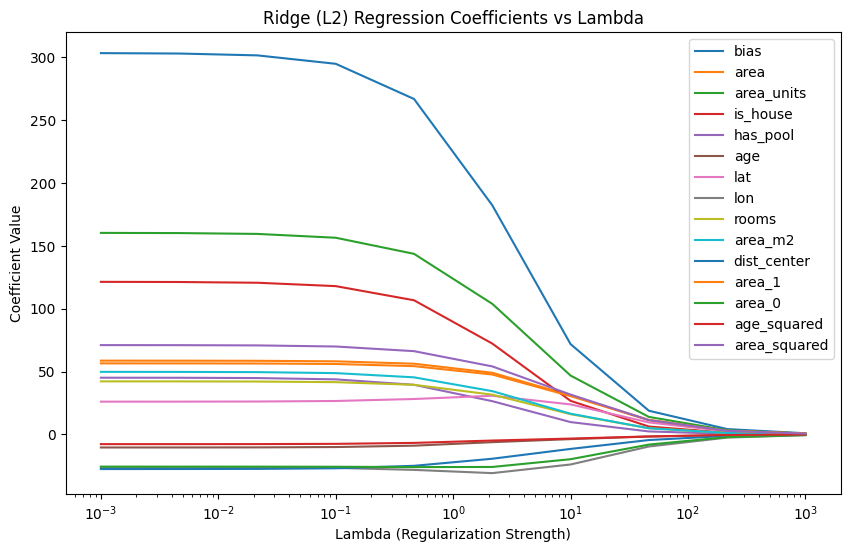

In [165]:
lambdas = np.logspace(-3, 3, 10) 
hiperparams.plot_regularization_coefficients(df_2, lambdas, reg_type="ridge")

### **Regularización L1 (Lasso)**

La regularización L1 (Lasso) penaliza la suma de los valores absolutos de los coeficientes del modelo, forzando a cero aquellos menos relevantes. Esto permite la selección automática de características, reduciendo la complejidad del modelo y mejorando su capacidad de generalización.


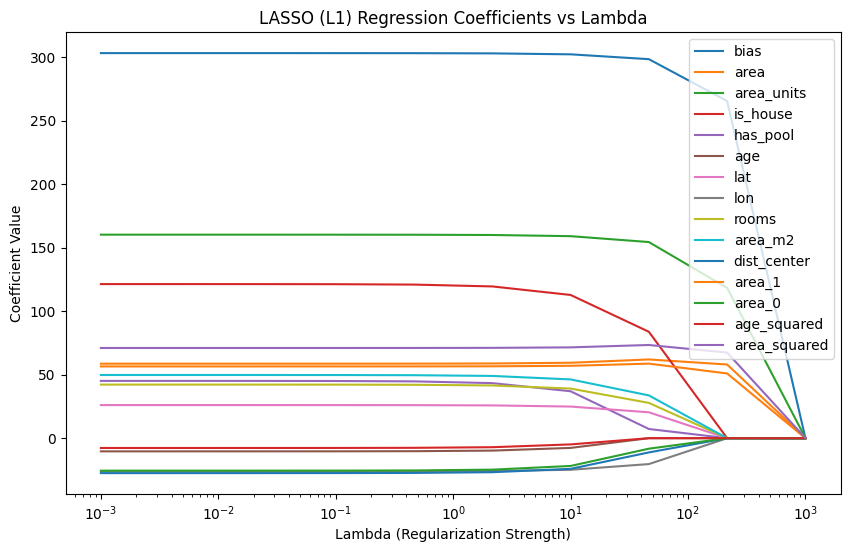

In [166]:
hiperparams.plot_regularization_coefficients(df_2, lambdas, reg_type="lasso")

Se eligió el valor de $ \lambda $ basándose en el gráfico de coeficientes vs. regularización. A medida que $ \lambda $ aumenta, los coeficientes se reducen gradualmente, evitando el sobreajuste. Un valor alrededor de $ 10^1 $ o $ 10^2 $ parece adecuado, ya que disminuye la complejidad del modelo sin colapsar completamente los coeficientes.  


In [167]:
X_train, X_val, y_train, y_val = preprocessing.split_and_normalize(df_2[['area_1', 'area_0', 'is_house', 'has_pool', 'age', 'lat', 'lon', 'dist_center','area_units','price']])
lambda_optimo = 0.1

model = models.LinearRegression(X_train, y_train)

print("Training with Gradient Descent and L2 Regularization:")
model.train_gradient_descent(l2_lambda=lambda_optimo)
y_pred_val = model.predict(X_val)
metrics.print_metrics(y_val, y_pred_val, "Validation")

Training with Gradient Descent and L2 Regularization:
Validation Metrics:
- MSE: 21004.89
- RMSE: 144.93
- MAE: 100.89
- R^2: 0.82



### **Ajusde de Hiperparámetros**

Ahora vamos a ajustar el hiperparámetro lambda para encontrar el mejor valor que minimice el error cuadrático medio (ECM) en el conjunto de validación. Para ello, utilizaremos dos enfoques: validación simple y validación cruzada.

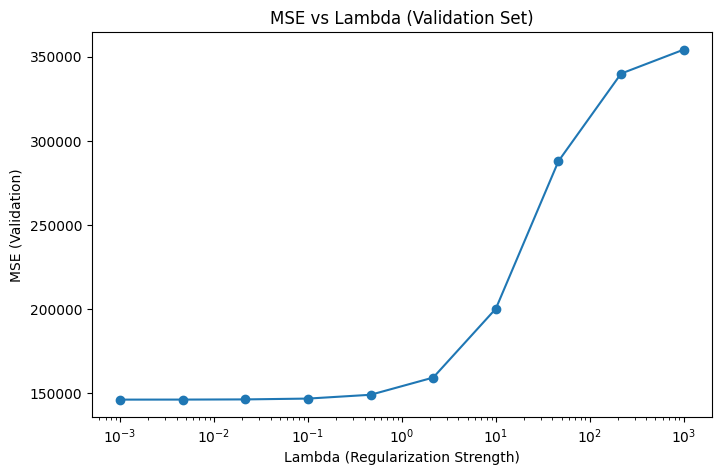

Mejor lambda (validación simple): 0.001


In [168]:
best_lambda_val, mse_values_val = hiperparams.find_best_lambda_validation(df, lambdas)
print(f"Mejor lambda (validación simple): {best_lambda_val}")

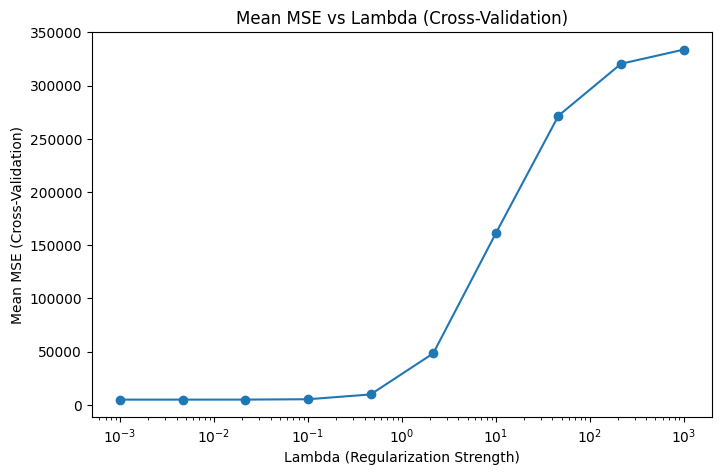

Mejor lambda (validación cruzada): 0.001


In [169]:
best_lambda_cv, mse_values_cv = hiperparams.find_best_lambda_cross_validation(df, lambdas, k=5)
print(f"Mejor lambda (validación cruzada): {best_lambda_cv}")

In [170]:
model.train_gradient_descent(l2_lambda=best_lambda_cv)
y_pred_val = model.predict(X_val)
metrics.print_metrics(y_val, y_pred_val, "Validation")

Validation Metrics:
- MSE: 19851.74
- RMSE: 140.90
- MAE: 98.51
- R^2: 0.83



### **Modelo Final y Evaluación en el Conjunto de Testeo**
Viendo el funcionamiento de todos los modelos. EL modelo con mejor performance es el modelo entrenado con la pseudo inversa, haciendo feature engineering. 
Vamos a probarlo en el dataset de testeo.

In [171]:
X, means, stds = preprocessing.normalize(df_2.drop(columns=['price']))
y = df_2['price']
cols = ['area_units', 'is_house', 'has_pool', 'age', 'rooms', 'area_1', 'area_0']

model = models.LinearRegression(X[cols], y)
model.train_pseudoinverse()

df_test = pd.read_csv("../data/casas_test.csv")
df_test = preprocessing.preprocess_data(df_test)
df_test = preprocessing.add_features(df_test)
df_test,_,_ = preprocessing.normalize(df_test, means, stds)

y_test_pred = model.predict(df_test[cols])
metrics.print_metrics(df_test['price'], y_test_pred, 'Test')

model.print_coefficients()


Test Metrics:
- MSE: 6797.73
- RMSE: 82.45
- MAE: 52.59
- R^2: 0.93

Model Coefficients:
bias: 428.99
area_units: 1.13
is_house: 70.94
has_pool: 48.08
age: -14.63
rooms: 11.51
area_1: 410.81
area_0: 81.45

